In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3080 Laptop GPU


# 1. Pre-process

Load data

In [2]:
import pandas as pd
import numpy as np
import os
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
import time
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             f1_score, accuracy_score, cohen_kappa_score)
from sklearn.model_selection import train_test_split

df = pd.read_csv("dataset/S025_whole_df.csv")
df.head()

,TIMESTAMP,BVP,ACC_X,ACC_Y,ACC_Z,TEMP,EDA,HR,IBI,Sleep_Stage,Obstructive_Apnea,Central_Apnea,Hypopnea,Multiple_Events
0,0.000000,140.76,-40.0,7.0,50.0,33.59,0.034544,60.0,NaN,P,NaN,NaN,NaN,NaN
1,0.015625,135.32,-40.0,7.0,50.0,33.59,0.034544,60.0,NaN,P,NaN,NaN,NaN,NaN
2,0.031250,130.88,-41.0,7.0,49.0,33.59,0.034544,60.0,NaN,P,NaN,NaN,NaN,NaN
3,0.046875,118.15,-41.0,7.0,49.0,33.59,0.034544,60.0,NaN,P,NaN,NaN,NaN,NaN
4,0.062500,92.38,-41.0,8.0,50.0,33.59,0.034544,60.0,NaN,P,NaN,NaN,NaN,NaN


Clear previous results

In [3]:
checkpoint_dir = './checkpoints/'

if os.path.exists(checkpoint_dir):
    for item in os.listdir(checkpoint_dir):
        if 'sleep_stage_test' in item:
            dir_path = os.path.join(checkpoint_dir, item)
            shutil.rmtree(dir_path)
            print(f": {dir_path}")

print("Model reseted")

files_to_delete = [
    "X_train.npy", "y_train.npy",
    "X_val.npy", "y_val.npy",
    "X_test.npy", "y_test.npy"
]

save_dir = "./dataset/sleep_data_ready/"
os.makedirs(save_dir, exist_ok=True)
print("Deleteing...")
for file in files_to_delete:
    file_path = os.path.join(save_dir, file)
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f" - Cleaned: {file}")
    else:
        print(f" - skip: {file}")

if os.path.exists('./test_results/'):
    shutil.rmtree('./test_results/')
    print("test_results deleted")

: ./checkpoints/classification_sleep_stage_test_TimesNet_sleep_ftM_sl1920_ll48_pl0_dm32_nh8_el2_dl1_df64_expand2_dc4_fc1_ebtimeF_dtTrue_test_0
Model reseted
Deleteing...
 - Cleaned: X_train.npy
 - Cleaned: y_train.npy
 - Cleaned: X_val.npy
 - Cleaned: y_val.npy
 - Cleaned: X_test.npy
 - Cleaned: y_test.npy
test_results deleted


Select Feature and Target, check missing value

In [4]:
features = ['BVP', 'IBI', 'EDA', 'TEMP', 'ACC_X', 'ACC_Y', 'ACC_Z', 'HR']
label_col = 'Sleep_Stage'

stage_counts = df['Sleep_Stage'].value_counts(dropna=False)
print(stage_counts)

missing_before = df[features].isna().sum().sum()
print(f" Missing Before: {missing_before} ")

Sleep_Stage
N2    858240
W     412801
P     406592
R     240000
N1     74880
Name: count, dtype: int64
 Missing Before: 2488 


Fill the missing value by taking average of the previous and the next value

In [5]:
df[features] = df[features].interpolate(method='linear', limit_direction='both')
missing_after = df[features].isna().sum().sum()
print(f"Missing After:{missing_after}")

Missing After:0


Slice Data

In [6]:
window_size = 1920
n_samples = len(df) // window_size

X_list = []
y_list = []

for i in range(n_samples):
    start_idx = i * window_size
    end_idx = start_idx + window_size
    
    window_df = df.iloc[start_idx:end_idx]
    
    mode_series = window_df[label_col].mode()
    if mode_series.empty:
        continue
    label = mode_series.iloc[0]
    
    if label in ['P','Missing']:
        continue
        
    X_list.append(window_df[features].values)
    y_list.append(label)

X = np.array(X_list)
y = np.array(y_list)

print("X shape", X.shape) 
print("y shape:", y.shape)
print("Label head", y[:5])

X shape (825, 1920, 8)
y shape: (825,)
Label head ['W' 'W' 'W' 'W' 'W']


In [7]:
label_map = {'W': 0, 'N1': 1, 'N2': 2, 'N3': 3, 'R': 4}
y_encoded = np.array([label_map[label] for label in y])

print("label to num head", y_encoded[:5])

label to num head [0 0 0 0 0]


# 2. Single patient training

Split and save data

In [8]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y_encoded, test_size=0.2, shuffle=False, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.125, shuffle=False, random_state=42)

print(" X_train:", X_train.shape, "y_train:", y_train.shape)
print(" X_val:", X_val.shape, "y_val:", y_val.shape)
print(" X_test:", X_test.shape, "y_test:", y_test.shape)

np.save(os.path.join(save_dir, "X_train.npy"), X_train)
np.save(os.path.join(save_dir, "y_train.npy"), y_train)
np.save(os.path.join(save_dir, "X_val.npy"), X_val)
np.save(os.path.join(save_dir, "y_val.npy"), y_val)
np.save(os.path.join(save_dir, "X_test.npy"), X_test)
np.save(os.path.join(save_dir, "y_test.npy"), y_test)

print(f"Data saved: {save_dir}")
results_dir = './test_results/'

 X_train: (577, 1920, 8) y_train: (577,)
 X_val: (83, 1920, 8) y_val: (83,)
 X_test: (165, 1920, 8) y_test: (165,)
Data saved: ./dataset/sleep_data_ready/


Train

In [9]:
!python -X utf8 run.py \
  --task_name classification \
  --is_training 1 \
  --model_id sleep_stage_test \
  --model TimesNet \
  --data sleep \
  --root_path ./dataset/sleep_data_ready/ \
  --seq_len 1920 \
  --enc_in 8 \
  --c_out 5 \
  --batch_size 32 \
  --d_model 32 \
  --d_ff 64 \
  --num_workers 0 \
  --dropout 0.5 \
  --learning_rate 0.00001 \
  --train_epochs 20 \
  --patience 5

Using GPU
Args in experiment:
Basic Config
  Task Name:          classification      Is Training:        1                   
  Model ID:           sleep_stage_test    Model:              TimesNet            

Data Loader
  Data:               sleep               Root Path:          ./dataset/sleep_data_ready/
  Data Path:          ETTh1.csv           Features:           M                   
  Target:             OT                  Freq:               h                   
  Checkpoints:        ./checkpoints/      

Model Parameters
  Top k:              5                   Num Kernels:        6                   
  Enc In:             8                   Dec In:             7                   
  C Out:              5                   d model:            32                  
  n heads:            8                   e layers:           2                   
  d layers:           1                   d FF:               64                  
  Moving Avg:         25                  Fact

Graph

Accuracy              : 0.4303
Cohen's Kappa         : -0.0051
Macro-F1 (all 5 cls)  : 0.1678
Macro-F1 (present 3 cls): 0.2797
All Stages            : ['W', 'N1', 'N2']
              precision    recall  f1-score   support

           W       0.56      0.14      0.22        36
          N1       0.00      0.00      0.00        21
          N2       0.62      0.61      0.62       108
          N3       0.00      0.00      0.00         0
           R       0.00      0.00      0.00         0

    accuracy                           0.43       165
   macro avg       0.24      0.15      0.17       165
weighted avg       0.53      0.43      0.45       165



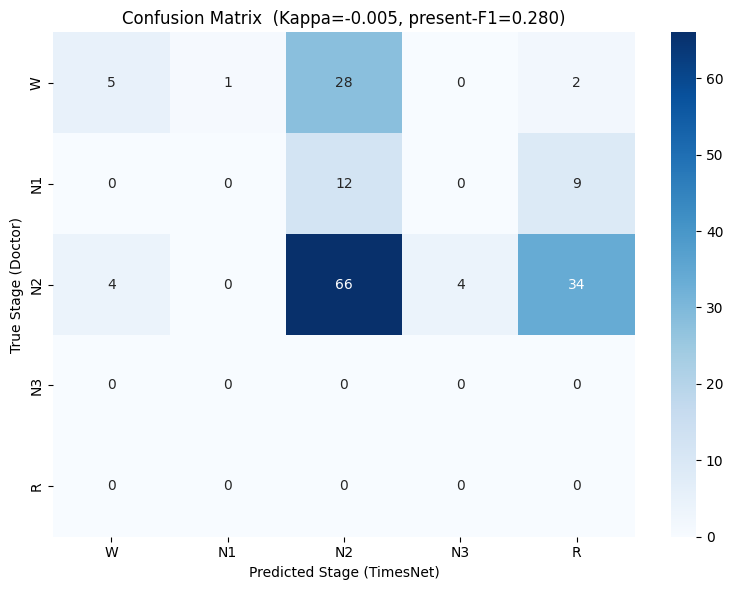

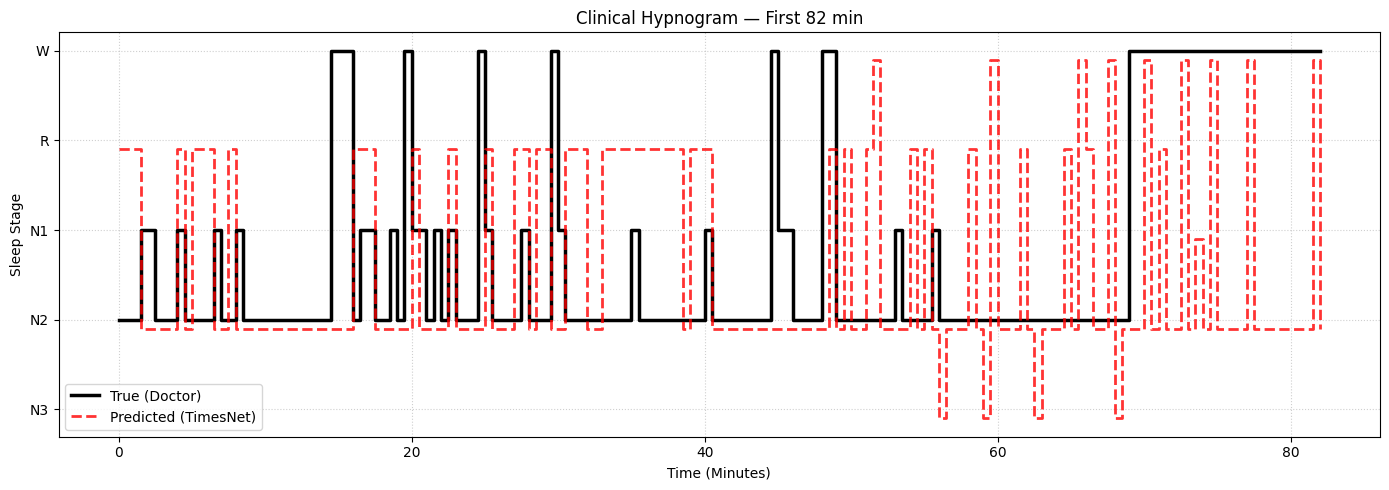

In [10]:
subdirs = [os.path.join(results_dir, d) for d in os.listdir(results_dir)
           if os.path.isdir(os.path.join(results_dir, d))]
subdirs.sort(key=os.path.getmtime)
latest_subdir = subdirs[-1]
y_pred = np.load(os.path.join(latest_subdir, 'pred.npy'))
y_true = np.load(os.path.join(latest_subdir, 'true.npy'))
if y_pred.ndim > 1 and y_pred.shape[1] > 1:
    y_pred = np.argmax(y_pred, axis=1)
y_true = y_true.astype(int); y_pred = y_pred.astype(int)

labels = ['W', 'N1', 'N2', 'N3', 'R']

present = sorted(np.unique(y_true).tolist())  
present_names = [labels[i] for i in present]

acc          = accuracy_score(y_true, y_pred)
kappa        = cohen_kappa_score(y_true, y_pred)
macro_f1_5   = f1_score(y_true, y_pred, labels=[0,1,2,3,4], average='macro', zero_division=0)
macro_f1_pre = f1_score(y_true, y_pred, labels=present,     average='macro', zero_division=0)

print("="*55)
print(f"Accuracy              : {acc:.4f}")
print(f"Cohen's Kappa         : {kappa:.4f}")
print(f"Macro-F1 (all 5 cls)  : {macro_f1_5:.4f}")
print(f"Macro-F1 (present {len(present)} cls): {macro_f1_pre:.4f}")
print(f"All Stages            : {present_names}")
print("="*55)
print(classification_report(y_true, y_pred, labels=[0,1,2,3,4],
                            target_names=labels, zero_division=0))

# ============================================================
# Confusion Matrix
# ============================================================
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred, labels=[0,1,2,3,4])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title(f"Confusion Matrix  (Kappa={kappa:.3f}, present-F1={macro_f1_pre:.3f})")
plt.xlabel('Predicted Stage (TimesNet)')
plt.ylabel('True Stage (Doctor)')
plt.tight_layout(); plt.show()

# ============================================================
# Hypnogram
# ============================================================
clinical_order = [0, 4, 1, 2, 3]           # W, R, N1, N2, N3
clinical_labels = ['W', 'R', 'N1', 'N2', 'N3']
y_true_c = [-clinical_order.index(v) for v in y_true]
y_pred_c = [-clinical_order.index(v) for v in y_pred]
n = min(600, len(y_true))
t = np.arange(n) * 0.5
plt.figure(figsize=(14, 5))
plt.step(t, y_true_c[:n], label='True (Doctor)', color='black', lw=2.5, where='post')
plt.step(t, [y-0.1 for y in y_pred_c[:n]], label='Predicted (TimesNet)',
         color='red', ls='--', lw=2, where='post', alpha=0.8)
plt.yticks([0,-1,-2,-3,-4], clinical_labels)
plt.title(f'Clinical Hypnogram — First {n*0.5:.0f} min')
plt.xlabel('Time (Minutes)'); plt.ylabel('Sleep Stage')
plt.legend(loc='lower left'); plt.grid(True, ls=':', alpha=0.6)
plt.tight_layout(); plt.show()

# 3. Cross patient training

Seleted patient at average for validation and average set

In [11]:
info_df = pd.read_csv('./dataset/participant_info.csv', dtype=str)
info_df['SID'] = info_df['SID'].astype(str).str.strip()

info_df = info_df.dropna(subset=['SID'])
info_df['SID'] = info_df['SID'].astype(str).str.strip()
info_df = info_df[info_df['SID'].str.lower() != 'nan']
info_df = info_df[info_df['SID'] != '']

features = ['AGE', 'BMI', 'OAHI', 'AHI', 'Mean_SaO2', 'Arousal Index']

if 'Mean_SaO2' in info_df.columns:
    info_df['Mean_SaO2'] = info_df['Mean_SaO2'].astype(str).str.replace('%', '', regex=False)


for col in features:
    info_df[col] = pd.to_numeric(info_df[col], errors='coerce')


global_means = info_df[features].mean()
global_stds = info_df[features].std()

for col in features:
    print(f" - {col}: Mean = {global_means[col]:.2f}, Std = {global_stds[col]:.2f}")


def calculate_multidimensional_distance(row):
    dist_sq = 0
    for col in features:
        if pd.isna(row[col]):
            continue
        z_score = (row[col] - global_means[col]) / global_stds[col]
        dist_sq += z_score ** 2  
    return np.sqrt(dist_sq)

info_df['Distance_to_Centroid'] = info_df.apply(calculate_multidimensional_distance, axis=1)

best_multidim_average = info_df.loc[info_df['Distance_to_Centroid'].idxmin()]

print("\n--- top 5 ---")
top5_candidates = info_df.sort_values(by='Distance_to_Centroid').head(5)
print(top5_candidates[['SID'] + features + ['Distance_to_Centroid']])

 - AGE: Mean = 56.24, Std = 16.56
 - BMI: Mean = 33.66, Std = 8.58
 - OAHI: Mean = 19.39, Std = 27.47
 - AHI: Mean = 22.13, Std = 28.68
 - Mean_SaO2: Mean = 94.07, Std = 3.13
 - Arousal Index: Mean = 37.72, Std = 25.69

--- top 5 ---
     SID    AGE   BMI  OAHI  AHI  Mean_SaO2  Arousal Index  \
22  S081  55.35  37.0    17   18         94             32   
48  S054  60.41  37.0    24   24         93             43   
87  S014  51.94  32.0    20   21         96             44   
12  S091  51.01  31.0     9   10         95             38   
84  S017  58.08  32.0     9   30         96             47   

    Distance_to_Centroid  
22              0.482939  
48              0.638148  
87              0.739632  
12              0.778345  
84              0.882759  


In [12]:
files_to_delete = [
    "X_train.npy", "y_train.npy",
    "X_val.npy", "y_val.npy",
    "X_test.npy", "y_test.npy"
]

print("Deleting...")
for file in files_to_delete:
    file_path = os.path.join(save_dir, file)
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f" Cleaned: {file}")
    else:
        print(f" - Skip: {file}")

Deleting...
 Cleaned: X_train.npy
 Cleaned: y_train.npy
 Cleaned: X_val.npy
 Cleaned: y_val.npy
 Cleaned: X_test.npy
 Cleaned: y_test.npy


Declear train set, val set, and test sets

In [13]:
data_folder = './dataset/' 

train_sids = ['S005', 'S007', 'S010', 'S025', 'S028', 'S033',
              'S050', 'S054', 'S066', 'S067', 'S081',
              'S095', 'S100',
              'S074', 'S052', 'S087',      
              'S099', 'S064', 'S031']      

val_sids = ['S011', 'S029']

test_healthy_sid = 'S049'
test_severe_sid  = 'S072'      
test_avg_sid     = 'S014'

def process_single_patient(sid, data_dir='./dataset/', window_size=1920):
    print(f"---running on {sid}---")
    file_path = os.path.join(data_dir, f"{sid}_whole_df.csv") 
    
    df = pd.read_csv(file_path)
    
    features_cols = ['BVP', 'IBI', 'EDA', 'TEMP', 'ACC_X', 'ACC_Y', 'ACC_Z', 'HR']
    label_col = 'Sleep_Stage'
    
    missing_before = df[features_cols].isna().sum().sum()
    print(f"Missing before: {missing_before}")
    
    df[features_cols] = df[features_cols].interpolate(method='linear', limit_direction='both')
    
    
    missing_after = df[features_cols].isna().sum().sum()
    print(f"Missing after: {missing_after}") 
    
    scaler = StandardScaler()
    df[features_cols] = scaler.fit_transform(df[features_cols])
    
    return df


print("------test signle------")
df_healthy = process_single_patient(test_healthy_sid)
df_severe = process_single_patient(test_severe_sid)
df_avg = process_single_patient(test_avg_sid)
val_dfs = {sid: process_single_patient(sid) for sid in val_sids}
print("------train set------")
train_dfs = {} 

for sid in train_sids:
    train_dfs[sid] = process_single_patient(sid)

------test signle------
---running on S049---
Missing before: 426
Missing after: 0
---running on S072---
Missing before: 2070
Missing after: 0
---running on S014---
Missing before: 3195
Missing after: 0
---running on S011---
Missing before: 657
Missing after: 0
---running on S029---
Missing before: 1866
Missing after: 0
------train set------
---running on S005---
Missing before: 148
Missing after: 0
---running on S007---
Missing before: 20183
Missing after: 0
---running on S010---
Missing before: 20211
Missing after: 0
---running on S025---
Missing before: 2488
Missing after: 0
---running on S028---
Missing before: 289
Missing after: 0
---running on S033---
Missing before: 257
Missing after: 0
---running on S050---
Missing before: 5730
Missing after: 0
---running on S054---
Missing before: 922
Missing after: 0
---running on S066---
Missing before: 11380
Missing after: 0
---running on S067---
Missing before: 91554
Missing after: 0
---running on S081---
Missing before: 2971
Missing after

Slice

In [14]:
def create_windows(df, window_size=1920):
    features_cols = ['BVP', 'IBI', 'EDA', 'TEMP', 'ACC_X', 'ACC_Y', 'ACC_Z', 'HR']
    label_col = 'Sleep_Stage'
    
    n_samples = len(df) // window_size
    X_list = []
    y_list = []
    
    for i in range(n_samples):
        start_idx = i * window_size
        end_idx = start_idx + window_size
        
        window_df = df.iloc[start_idx:end_idx]
        
        mode_series = window_df[label_col].mode()
        if mode_series.empty:
            continue
        label = mode_series.iloc[0]
        
        if str(label).strip() in ['P', 'Missing']:
            continue
            
        X_list.append(window_df[features_cols].values)
        y_list.append(label)

    return np.array(X_list), np.array(y_list)

print("------ single slice ------")
X_val_list, y_val_list = [], []
for sid in val_sids:
    Xv, yv = create_windows(val_dfs[sid])
    X_val_list.append(Xv)
    y_val_list.append(yv)
    print(f"  {sid} val X: {Xv.shape}")
X_val = np.concatenate(X_val_list, axis=0)
y_val = np.concatenate(y_val_list, axis=0)
print(f"val total X: {X_val.shape}, y: {y_val.shape}")

X_test_healthy, y_test_healthy = create_windows(df_healthy)
print(f"healthy test X: {X_test_healthy.shape}, y: {y_test_healthy.shape}")

X_test_severe, y_test_severe = create_windows(df_severe)
print(f"severe test X: {X_test_severe.shape}, y: {y_test_severe.shape}")

X_test_avg, y_test_avg = create_windows(df_avg)
print(f"avg test X: {X_test_avg.shape}, y: {y_test_avg.shape}")

print("\n------ group slice ------")
X_train_list = []
y_train_list = []

for sid in train_sids:
    print(f"sclicing data for {sid}...")
    
    clean_df = train_dfs[sid] 
    X_temp, y_temp = create_windows(clean_df)
    
    X_train_list.append(X_temp)
    y_train_list.append(y_temp)

X_train = np.concatenate(X_train_list, axis=0)
y_train = np.concatenate(y_train_list, axis=0)

print(f"\n X_train: {X_train.shape}, y_train: {y_train.shape}")

------ single slice ------
  S011 val X: (813, 1920, 8)
  S029 val X: (804, 1920, 8)
val total X: (1617, 1920, 8), y: (1617,)
healthy test X: (794, 1920, 8), y: (794,)
severe test X: (732, 1920, 8), y: (732,)
avg test X: (796, 1920, 8), y: (796,)

------ group slice ------
sclicing data for S005...
sclicing data for S007...
sclicing data for S010...
sclicing data for S025...
sclicing data for S028...
sclicing data for S033...
sclicing data for S050...
sclicing data for S054...
sclicing data for S066...
sclicing data for S067...
sclicing data for S081...
sclicing data for S095...
sclicing data for S100...
sclicing data for S074...
sclicing data for S052...
sclicing data for S087...
sclicing data for S099...
sclicing data for S064...
sclicing data for S031...

 X_train: (15163, 1920, 8), y_train: (15163,)


Encode data and start testing with average set

In [15]:
label_map = {'W': 0, 'N1': 1, 'N2': 2, 'N3': 3, 'R': 4}

def encode_labels(y_array, mapping):
    return np.array([mapping[label] for label in y_array])

y_train_encoded = encode_labels(y_train, label_map)
y_val_encoded = encode_labels(y_val, label_map)
y_test_healthy_encoded = encode_labels(y_test_healthy, label_map)
y_test_severe_encoded = encode_labels(y_test_severe, label_map)
y_test_avg_encoded = encode_labels(y_test_avg, label_map)

print(f"lable changed: {y_train_encoded[:5]}")

print("\n------ shape varify ------")
print(f"X_train: {X_train.shape}, y_train: {y_train_encoded.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val_encoded.shape}")
print(f"X_test_healthy: {X_test_healthy.shape}, y_test_healthy: {y_test_healthy_encoded.shape}")
print(f"X_test_severe:  {X_test_severe.shape}, y_test_severe:  {y_test_severe_encoded.shape}")
print(f"X_test_avg:  {X_test_avg.shape}, y_test_avg:  {y_test_avg_encoded.shape}")

#save
save_dir = "./dataset/sleep_data_ready/"
os.makedirs(save_dir, exist_ok=True)

np.save(os.path.join(save_dir, "X_train.npy"), X_train)
np.save(os.path.join(save_dir, "y_train.npy"), y_train_encoded)
np.save(os.path.join(save_dir, "X_val.npy"), X_val)
np.save(os.path.join(save_dir, "y_val.npy"), y_val_encoded)
np.save(os.path.join(save_dir, "X_test.npy"), X_test_avg)
np.save(os.path.join(save_dir, "y_test.npy"), y_test_avg_encoded)


print(f"\nData saved: {save_dir}")
print("ready for training and average test")

lable changed: [0 0 0 1 0]

------ shape varify ------
X_train: (15163, 1920, 8), y_train: (15163,)
X_val:   (1617, 1920, 8), y_val:   (1617,)
X_test_healthy: (794, 1920, 8), y_test_healthy: (794,)
X_test_severe:  (732, 1920, 8), y_test_severe:  (732,)
X_test_avg:  (796, 1920, 8), y_test_avg:  (796,)

Data saved: ./dataset/sleep_data_ready/
ready for training and average test


In [16]:
def check_label_distribution(y_array, dataset_name):
    counts = Counter(y_array)

    reverse_map = {0: 'W', 1: 'N1', 2: 'N2', 3: 'N3', 4: 'R'}
    
    print(f" --- {dataset_name}  ---")
    total = len(y_array)
    if total == 0:
        print("empty \n")
        return
        
    for num_label in range(5):
        count = counts.get(num_label, 0)
        percentage = (count / total) * 100
        print(f"  {reverse_map[num_label]:<2} ({num_label}): {count:<5} ({percentage:>5.1f}%)")
    print(f" Total: {total} \n")

print("\n Checking Status：\n")
check_label_distribution(y_train_encoded, "Train")
check_label_distribution(y_val_encoded, "Val")
check_label_distribution(y_test_avg_encoded, "Test Avg (S014)")
check_label_distribution(y_test_healthy_encoded, "Test Healthy (S049)")
check_label_distribution(y_test_severe_encoded, "Test Severe (S072)")


 Checking Status：

 --- Train  ---
  W  (0): 3586  ( 23.6%)
  N1 (1): 1535  ( 10.1%)
  N2 (2): 8371  ( 55.2%)
  N3 (3): 279   (  1.8%)
  R  (4): 1392  (  9.2%)
 Total: 15163 

 --- Val  ---
  W  (0): 298   ( 18.4%)
  N1 (1): 116   (  7.2%)
  N2 (2): 888   ( 54.9%)
  N3 (3): 140   (  8.7%)
  R  (4): 175   ( 10.8%)
 Total: 1617 

 --- Test Avg (S014)  ---
  W  (0): 195   ( 24.5%)
  N1 (1): 31    (  3.9%)
  N2 (2): 431   ( 54.1%)
  N3 (3): 106   ( 13.3%)
  R  (4): 33    (  4.1%)
 Total: 796 

 --- Test Healthy (S049)  ---
  W  (0): 141   ( 17.8%)
  N1 (1): 22    (  2.8%)
  N2 (2): 546   ( 68.8%)
  N3 (3): 0     (  0.0%)
  R  (4): 85    ( 10.7%)
 Total: 794 

 --- Test Severe (S072)  ---
  W  (0): 437   ( 59.7%)
  N1 (1): 134   ( 18.3%)
  N2 (2): 161   ( 22.0%)
  N3 (3): 0     (  0.0%)
  R  (4): 0     (  0.0%)
 Total: 732 



In [17]:
checkpoint_dir = './checkpoints/'

if os.path.exists(checkpoint_dir):
    for item in os.listdir(checkpoint_dir):
        if 'sleep_stage_test' in item:
            dir_path = os.path.join(checkpoint_dir, item)
            shutil.rmtree(dir_path)
            print(f"Removed: {dir_path}")

print("Model Cleaned")

if os.path.exists('./test_results/'):
    shutil.rmtree('./test_results/')
    print("test_results deleted")

Removed: ./checkpoints/classification_sleep_stage_test_TimesNet_sleep_ftM_sl1920_ll48_pl0_dm32_nh8_el2_dl1_df64_expand2_dc4_fc1_ebtimeF_dtTrue_test_0
Model Cleaned
test_results deleted


Train

In [18]:
!python -X utf8 run.py \
  --task_name classification \
  --is_training 1 \
  --model_id sleep_stage_test \
  --model TimesNet \
  --data sleep \
  --root_path ./dataset/sleep_data_ready/ \
  --seq_len 1920 \
  --enc_in 8 \
  --c_out 5 \
  --batch_size 32 \
  --d_model 32 \
  --d_ff 64 \
  --num_workers 0 \
  --dropout 0.5 \
  --learning_rate 0.00001 \
  --train_epochs 20 \
  --patience 5

Using GPU
Args in experiment:
Basic Config
  Task Name:          classification      Is Training:        1                   
  Model ID:           sleep_stage_test    Model:              TimesNet            

Data Loader
  Data:               sleep               Root Path:          ./dataset/sleep_data_ready/
  Data Path:          ETTh1.csv           Features:           M                   
  Target:             OT                  Freq:               h                   
  Checkpoints:        ./checkpoints/      

Model Parameters
  Top k:              5                   Num Kernels:        6                   
  Enc In:             8                   Dec In:             7                   
  C Out:              5                   d model:            32                  
  n heads:            8                   e layers:           2                   
  d layers:           1                   d FF:               64                  
  Moving Avg:         25                  Fact

Accuracy              : 0.5339
Cohen's Kappa         : 0.2493
Macro-F1 (all 5 cls)  : 0.2696
Macro-F1 (present 5 cls): 0.2696
All Stages            : ['W', 'N1', 'N2', 'N3', 'R']
              precision    recall  f1-score   support

           W       0.58      0.61      0.59       195
          N1       0.05      0.16      0.07        31
          N2       0.67      0.70      0.68       431
          N3       0.00      0.00      0.00       106
           R       0.00      0.00      0.00        33

    accuracy                           0.53       796
   macro avg       0.26      0.29      0.27       796
weighted avg       0.51      0.53      0.52       796



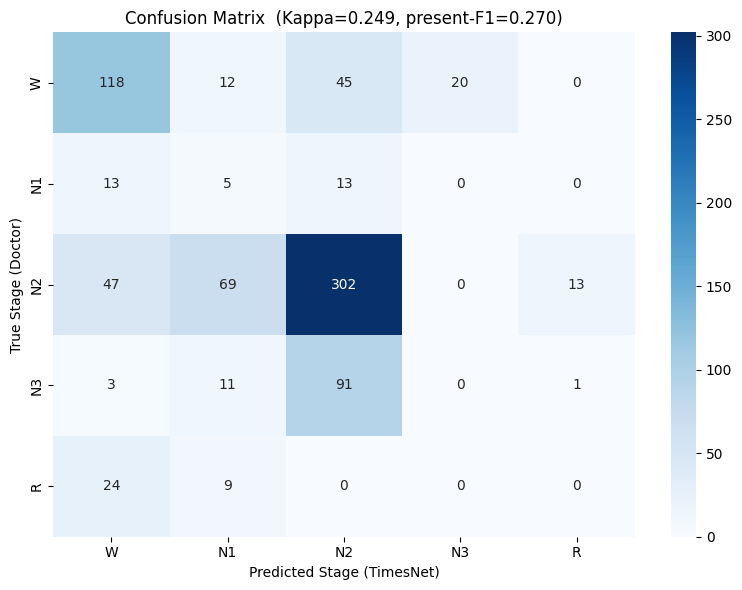

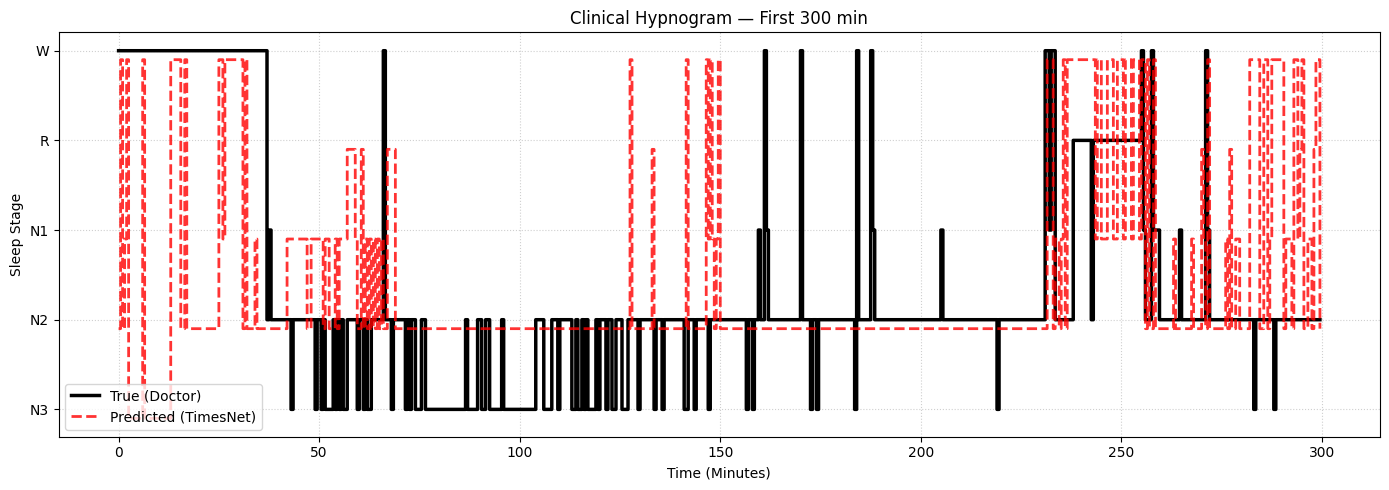

In [19]:
subdirs = [os.path.join(results_dir, d) for d in os.listdir(results_dir)
           if os.path.isdir(os.path.join(results_dir, d))]
subdirs.sort(key=os.path.getmtime)
latest_subdir = subdirs[-1]
y_pred = np.load(os.path.join(latest_subdir, 'pred.npy'))
y_true = np.load(os.path.join(latest_subdir, 'true.npy'))
if y_pred.ndim > 1 and y_pred.shape[1] > 1:
    y_pred = np.argmax(y_pred, axis=1)
y_true = y_true.astype(int); y_pred = y_pred.astype(int)

labels = ['W', 'N1', 'N2', 'N3', 'R']

present = sorted(np.unique(y_true).tolist())  
present_names = [labels[i] for i in present]

acc          = accuracy_score(y_true, y_pred)
kappa        = cohen_kappa_score(y_true, y_pred)
macro_f1_5   = f1_score(y_true, y_pred, labels=[0,1,2,3,4], average='macro', zero_division=0)
macro_f1_pre = f1_score(y_true, y_pred, labels=present,     average='macro', zero_division=0)

print("="*55)
print(f"Accuracy              : {acc:.4f}")
print(f"Cohen's Kappa         : {kappa:.4f}")
print(f"Macro-F1 (all 5 cls)  : {macro_f1_5:.4f}")
print(f"Macro-F1 (present {len(present)} cls): {macro_f1_pre:.4f}")
print(f"All Stages            : {present_names}")
print("="*55)
print(classification_report(y_true, y_pred, labels=[0,1,2,3,4],
                            target_names=labels, zero_division=0))

# ============================================================
# Confusion Matrix
# ============================================================
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred, labels=[0,1,2,3,4])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title(f"Confusion Matrix  (Kappa={kappa:.3f}, present-F1={macro_f1_pre:.3f})")
plt.xlabel('Predicted Stage (TimesNet)')
plt.ylabel('True Stage (Doctor)')
plt.tight_layout(); plt.show()

# ============================================================
# Hypnogram
# ============================================================
clinical_order = [0, 4, 1, 2, 3]           # W, R, N1, N2, N3
clinical_labels = ['W', 'R', 'N1', 'N2', 'N3']
y_true_c = [-clinical_order.index(v) for v in y_true]
y_pred_c = [-clinical_order.index(v) for v in y_pred]
n = min(600, len(y_true))
t = np.arange(n) * 0.5
plt.figure(figsize=(14, 5))
plt.step(t, y_true_c[:n], label='True (Doctor)', color='black', lw=2.5, where='post')
plt.step(t, [y-0.1 for y in y_pred_c[:n]], label='Predicted (TimesNet)',
         color='red', ls='--', lw=2, where='post', alpha=0.8)
plt.yticks([0,-1,-2,-3,-4], clinical_labels)
plt.title(f'Clinical Hypnogram — First {n*0.5:.0f} min')
plt.xlabel('Time (Minutes)'); plt.ylabel('Sleep Stage')
plt.legend(loc='lower left'); plt.grid(True, ls=':', alpha=0.6)
plt.tight_layout(); plt.show()

Test with healthy set

In [20]:
files_to_delete = [
    "X_test.npy", "y_test.npy"
]

print("Deleting...")
for file in files_to_delete:
    file_path = os.path.join(save_dir, file)
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f" - Cleaned: {file}")
    else:
        print(f" - Skiped: {file}")


np.save(os.path.join(save_dir, "X_test.npy"), X_test_healthy)
np.save(os.path.join(save_dir, "y_test.npy"), y_test_healthy_encoded)
print("ready for healthy test")

if os.path.exists('./test_results/'):
    shutil.rmtree('./test_results/')
    print("test_results deleted")

Deleting...
 - Cleaned: X_test.npy
 - Cleaned: y_test.npy
ready for healthy test
test_results deleted


In [21]:
!python -X utf8 run.py \
  --task_name classification \
  --is_training 0 \
  --model_id sleep_stage_test \
  --model TimesNet \
  --data sleep \
  --root_path ./dataset/sleep_data_ready/ \
  --seq_len 1920 \
  --enc_in 8 \
  --c_out 5 \
  --batch_size 32 \
  --d_model 32 \
  --d_ff 64 \
  --num_workers 0 \
  --dropout 0.5 \
  --learning_rate 0.00001 \
  --train_epochs 20 \
  --patience 5

Using GPU
Args in experiment:
Basic Config
  Task Name:          classification      Is Training:        0                   
  Model ID:           sleep_stage_test    Model:              TimesNet            

Data Loader
  Data:               sleep               Root Path:          ./dataset/sleep_data_ready/
  Data Path:          ETTh1.csv           Features:           M                   
  Target:             OT                  Freq:               h                   
  Checkpoints:        ./checkpoints/      

Model Parameters
  Top k:              5                   Num Kernels:        6                   
  Enc In:             8                   Dec In:             7                   
  C Out:              5                   d model:            32                  
  n heads:            8                   e layers:           2                   
  d layers:           1                   d FF:               64                  
  Moving Avg:         25                  Fact

Accuracy              : 0.4824
Cohen's Kappa         : 0.0537
Macro-F1 (all 5 cls)  : 0.1914
Macro-F1 (present 4 cls): 0.2393
All Stages            : ['W', 'N1', 'N2', 'R']
              precision    recall  f1-score   support

           W       0.26      0.30      0.28       141
          N1       0.01      0.05      0.01        22
          N2       0.72      0.62      0.67       546
          N3       0.00      0.00      0.00         0
           R       0.00      0.00      0.00        85

    accuracy                           0.48       794
   macro avg       0.20      0.19      0.19       794
weighted avg       0.54      0.48      0.51       794



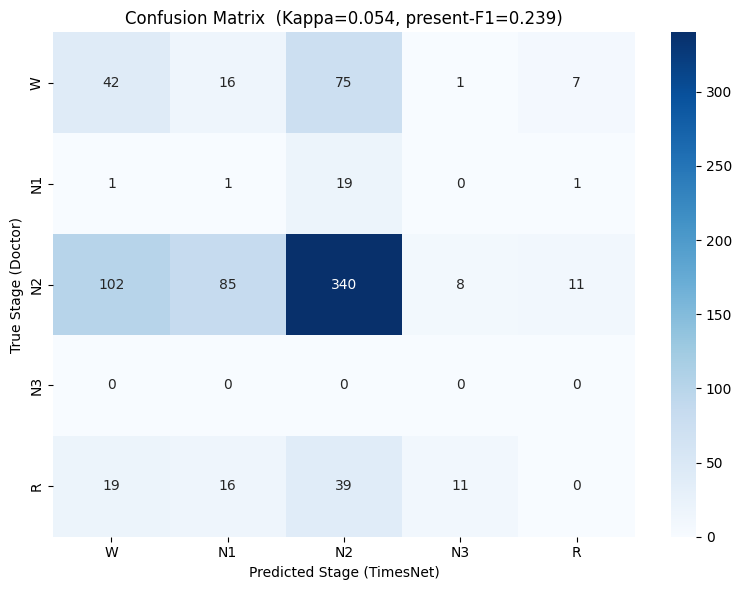

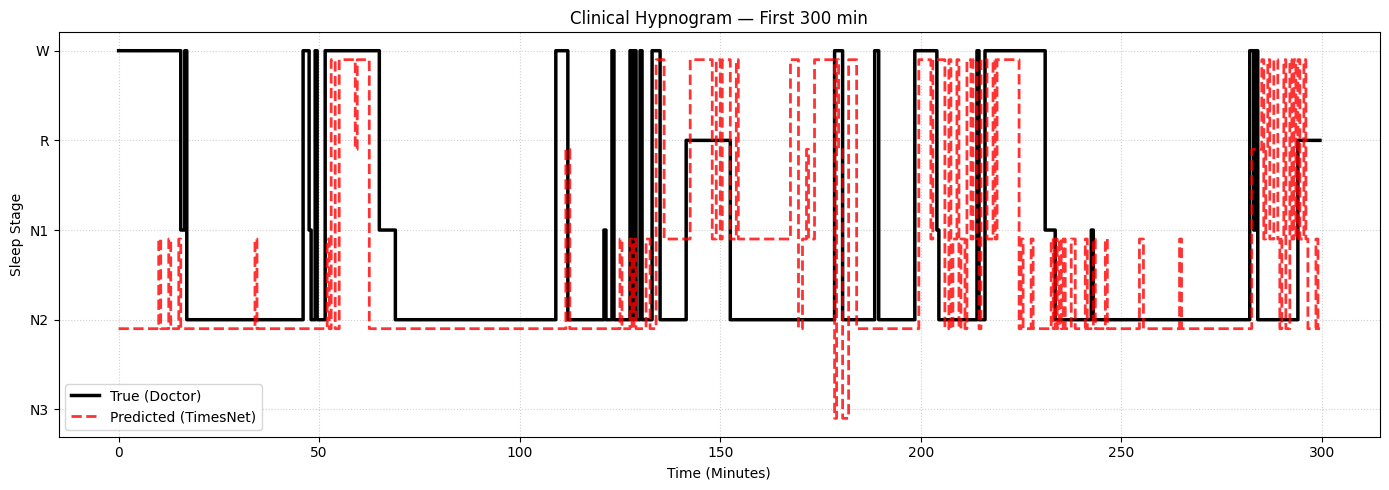

In [22]:
subdirs = [os.path.join(results_dir, d) for d in os.listdir(results_dir)
           if os.path.isdir(os.path.join(results_dir, d))]
subdirs.sort(key=os.path.getmtime)
latest_subdir = subdirs[-1]
y_pred = np.load(os.path.join(latest_subdir, 'pred.npy'))
y_true = np.load(os.path.join(latest_subdir, 'true.npy'))
if y_pred.ndim > 1 and y_pred.shape[1] > 1:
    y_pred = np.argmax(y_pred, axis=1)
y_true = y_true.astype(int); y_pred = y_pred.astype(int)

labels = ['W', 'N1', 'N2', 'N3', 'R']

present = sorted(np.unique(y_true).tolist())  
present_names = [labels[i] for i in present]

acc          = accuracy_score(y_true, y_pred)
kappa        = cohen_kappa_score(y_true, y_pred)
macro_f1_5   = f1_score(y_true, y_pred, labels=[0,1,2,3,4], average='macro', zero_division=0)
macro_f1_pre = f1_score(y_true, y_pred, labels=present,     average='macro', zero_division=0)

print("="*55)
print(f"Accuracy              : {acc:.4f}")
print(f"Cohen's Kappa         : {kappa:.4f}")
print(f"Macro-F1 (all 5 cls)  : {macro_f1_5:.4f}")
print(f"Macro-F1 (present {len(present)} cls): {macro_f1_pre:.4f}")
print(f"All Stages            : {present_names}")
print("="*55)
print(classification_report(y_true, y_pred, labels=[0,1,2,3,4],
                            target_names=labels, zero_division=0))

# ============================================================
# Confusion Matrix
# ============================================================
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred, labels=[0,1,2,3,4])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title(f"Confusion Matrix  (Kappa={kappa:.3f}, present-F1={macro_f1_pre:.3f})")
plt.xlabel('Predicted Stage (TimesNet)')
plt.ylabel('True Stage (Doctor)')
plt.tight_layout(); plt.show()

# ============================================================
# Hypnogram
# ============================================================
clinical_order = [0, 4, 1, 2, 3]           # W, R, N1, N2, N3
clinical_labels = ['W', 'R', 'N1', 'N2', 'N3']
y_true_c = [-clinical_order.index(v) for v in y_true]
y_pred_c = [-clinical_order.index(v) for v in y_pred]
n = min(600, len(y_true))
t = np.arange(n) * 0.5
plt.figure(figsize=(14, 5))
plt.step(t, y_true_c[:n], label='True (Doctor)', color='black', lw=2.5, where='post')
plt.step(t, [y-0.1 for y in y_pred_c[:n]], label='Predicted (TimesNet)',
         color='red', ls='--', lw=2, where='post', alpha=0.8)
plt.yticks([0,-1,-2,-3,-4], clinical_labels)
plt.title(f'Clinical Hypnogram — First {n*0.5:.0f} min')
plt.xlabel('Time (Minutes)'); plt.ylabel('Sleep Stage')
plt.legend(loc='lower left'); plt.grid(True, ls=':', alpha=0.6)
plt.tight_layout(); plt.show()

Test with severe set

In [23]:
files_to_delete = [
    "X_test.npy", "y_test.npy"
]

print("Deleting...")
for file in files_to_delete:
    file_path = os.path.join(save_dir, file)
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f" - Cleaned: {file}")
    else:
        print(f" - Skiped: {file}")


np.save(os.path.join(save_dir, "X_test.npy"), X_test_severe)
np.save(os.path.join(save_dir, "y_test.npy"), y_test_severe_encoded)
print("ready for severe test")

if os.path.exists('./test_results/'):
    shutil.rmtree('./test_results/')
    print("test_results deleted")

Deleting...
 - Cleaned: X_test.npy
 - Cleaned: y_test.npy
ready for severe test
test_results deleted


In [24]:
!python -X utf8 run.py \
  --task_name classification \
  --is_training 0 \
  --model_id sleep_stage_test \
  --model TimesNet \
  --data sleep \
  --root_path ./dataset/sleep_data_ready/ \
  --seq_len 1920 \
  --enc_in 8 \
  --c_out 5 \
  --batch_size 32 \
  --d_model 32 \
  --d_ff 64 \
  --num_workers 0 \
  --dropout 0.5 \
  --learning_rate 0.00001 \
  --train_epochs 20 \
  --patience 5

Using GPU
Args in experiment:
Basic Config
  Task Name:          classification      Is Training:        0                   
  Model ID:           sleep_stage_test    Model:              TimesNet            

Data Loader
  Data:               sleep               Root Path:          ./dataset/sleep_data_ready/
  Data Path:          ETTh1.csv           Features:           M                   
  Target:             OT                  Freq:               h                   
  Checkpoints:        ./checkpoints/      

Model Parameters
  Top k:              5                   Num Kernels:        6                   
  Enc In:             8                   Dec In:             7                   
  C Out:              5                   d model:            32                  
  n heads:            8                   e layers:           2                   
  d layers:           1                   d FF:               64                  
  Moving Avg:         25                  Fact

Accuracy              : 0.2787
Cohen's Kappa         : -0.0131
Macro-F1 (all 5 cls)  : 0.1427
Macro-F1 (present 3 cls): 0.2378
All Stages            : ['W', 'N1', 'N2']
              precision    recall  f1-score   support

           W       0.66      0.23      0.34       437
          N1       0.09      0.06      0.07       134
          N2       0.20      0.60      0.30       161
          N3       0.00      0.00      0.00         0
           R       0.00      0.00      0.00         0

   micro avg       0.28      0.28      0.28       732
   macro avg       0.19      0.18      0.14       732
weighted avg       0.45      0.28      0.28       732



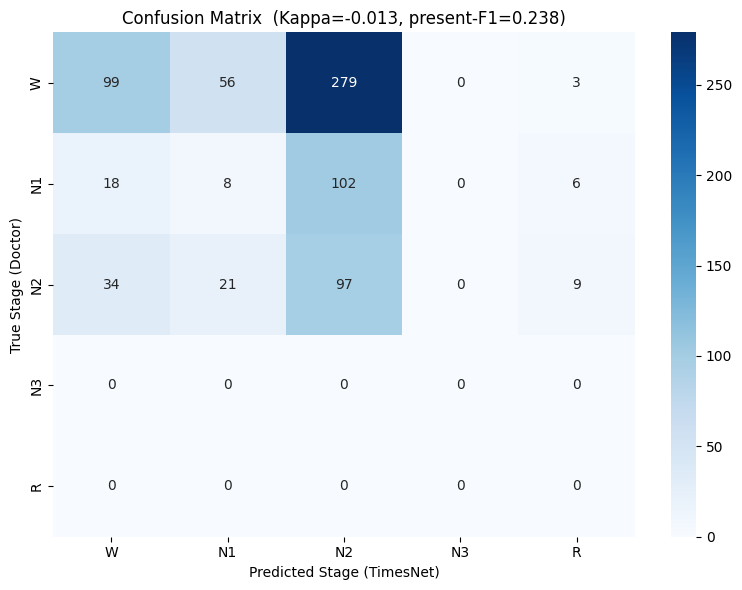

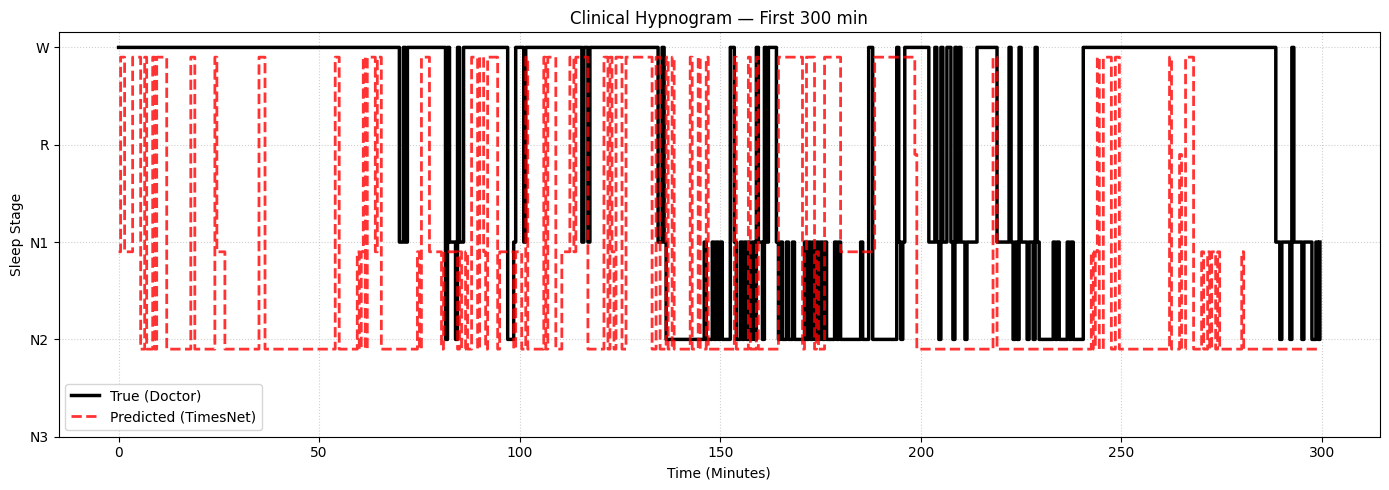

In [25]:
subdirs = [os.path.join(results_dir, d) for d in os.listdir(results_dir)
           if os.path.isdir(os.path.join(results_dir, d))]
subdirs.sort(key=os.path.getmtime)
latest_subdir = subdirs[-1]
y_pred = np.load(os.path.join(latest_subdir, 'pred.npy'))
y_true = np.load(os.path.join(latest_subdir, 'true.npy'))
if y_pred.ndim > 1 and y_pred.shape[1] > 1:
    y_pred = np.argmax(y_pred, axis=1)
y_true = y_true.astype(int); y_pred = y_pred.astype(int)

labels = ['W', 'N1', 'N2', 'N3', 'R']

present = sorted(np.unique(y_true).tolist())  
present_names = [labels[i] for i in present]

acc          = accuracy_score(y_true, y_pred)
kappa        = cohen_kappa_score(y_true, y_pred)
macro_f1_5   = f1_score(y_true, y_pred, labels=[0,1,2,3,4], average='macro', zero_division=0)
macro_f1_pre = f1_score(y_true, y_pred, labels=present,     average='macro', zero_division=0)

print("="*55)
print(f"Accuracy              : {acc:.4f}")
print(f"Cohen's Kappa         : {kappa:.4f}")
print(f"Macro-F1 (all 5 cls)  : {macro_f1_5:.4f}")
print(f"Macro-F1 (present {len(present)} cls): {macro_f1_pre:.4f}")
print(f"All Stages            : {present_names}")
print("="*55)
print(classification_report(y_true, y_pred, labels=[0,1,2,3,4],
                            target_names=labels, zero_division=0))

# ============================================================
# Confusion Matrix
# ============================================================
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred, labels=[0,1,2,3,4])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title(f"Confusion Matrix  (Kappa={kappa:.3f}, present-F1={macro_f1_pre:.3f})")
plt.xlabel('Predicted Stage (TimesNet)')
plt.ylabel('True Stage (Doctor)')
plt.tight_layout(); plt.show()

# ============================================================
# Hypnogram
# ============================================================
clinical_order = [0, 4, 1, 2, 3]           # W, R, N1, N2, N3
clinical_labels = ['W', 'R', 'N1', 'N2', 'N3']
y_true_c = [-clinical_order.index(v) for v in y_true]
y_pred_c = [-clinical_order.index(v) for v in y_pred]
n = min(600, len(y_true))
t = np.arange(n) * 0.5
plt.figure(figsize=(14, 5))
plt.step(t, y_true_c[:n], label='True (Doctor)', color='black', lw=2.5, where='post')
plt.step(t, [y-0.1 for y in y_pred_c[:n]], label='Predicted (TimesNet)',
         color='red', ls='--', lw=2, where='post', alpha=0.8)
plt.yticks([0,-1,-2,-3,-4], clinical_labels)
plt.title(f'Clinical Hypnogram — First {n*0.5:.0f} min')
plt.xlabel('Time (Minutes)'); plt.ylabel('Sleep Stage')
plt.legend(loc='lower left'); plt.grid(True, ls=':', alpha=0.6)
plt.tight_layout(); plt.show()

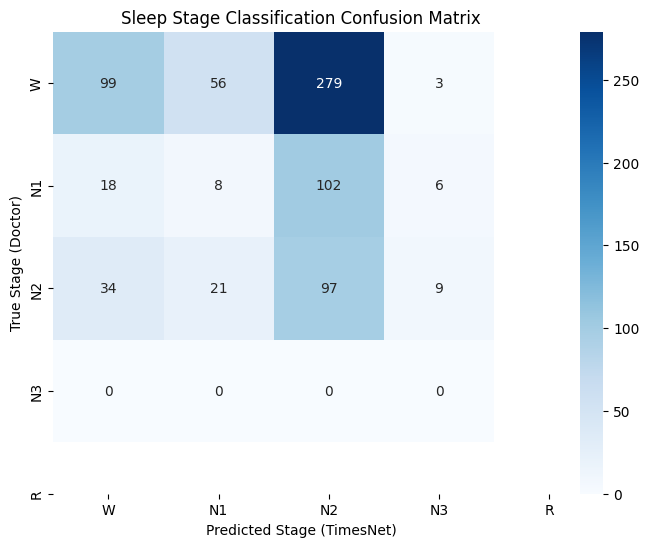

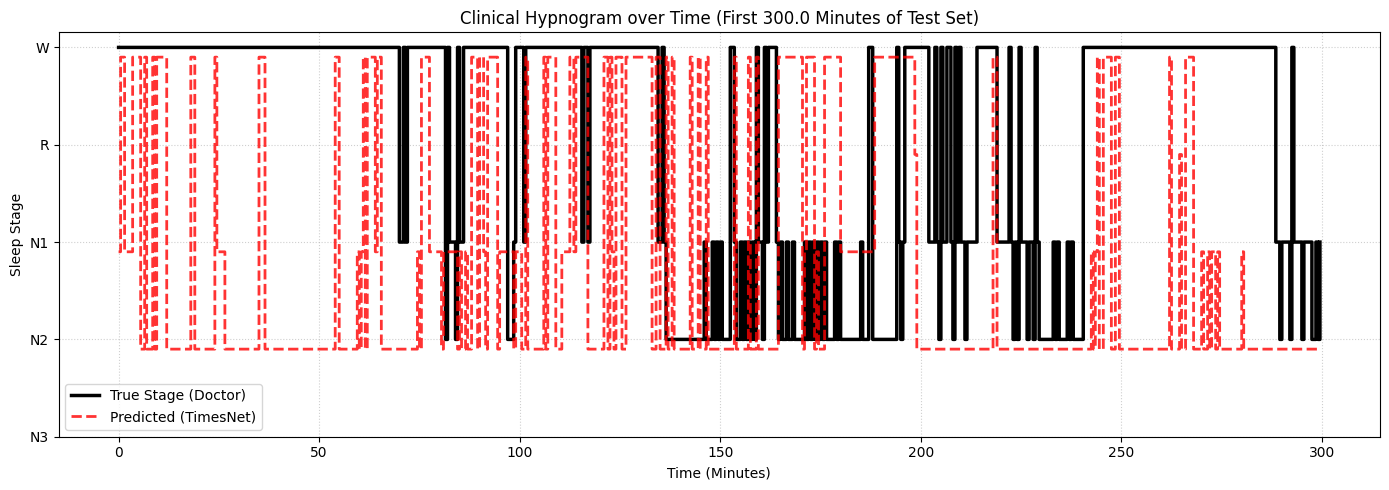

In [26]:
subdirs = [os.path.join(results_dir, d) for d in os.listdir(results_dir) if os.path.isdir(os.path.join(results_dir, d))]
subdirs.sort(key=os.path.getmtime)
latest_subdir = subdirs[-1]

pred_path = os.path.join(latest_subdir, 'pred.npy')
true_path = os.path.join(latest_subdir, 'true.npy')

y_pred = np.load(pred_path)
y_true = np.load(true_path)
if len(y_pred.shape) > 1 and y_pred.shape[1] > 1:
    y_pred = np.argmax(y_pred, axis=1)
labels = ['W', 'N1', 'N2', 'N3', 'R']

            
# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred)
            
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Sleep Stage Classification Confusion Matrix')
plt.xlabel('Predicted Stage (TimesNet)')
plt.ylabel('True Stage (Doctor)')
plt.show()

           
# Hypnogram
clinical_order = [0, 4, 1, 2, 3] # W, R, N1, N2, N3
y_true_clinical = [-clinical_order.index(val) for val in y_true]
y_pred_clinical = [-clinical_order.index(val) for val in y_pred]
clinical_labels = ['W', 'R', 'N1', 'N2', 'N3']
display_length = min(600, len(y_true)) 

y_true_display = y_true_clinical[:display_length]
y_pred_display = y_pred_clinical[:display_length]

time_axis = np.arange(display_length) * 0.5 

plt.figure(figsize=(14, 5))
            
plt.step(time_axis, y_true_display, label='True Stage (Doctor)', color='black', linewidth=2.5, where='post')
            
plt.step(time_axis, [y - 0.1 for y in y_pred_display], label='Predicted (TimesNet)', color='red', linestyle='--', linewidth=2, where='post', alpha=0.8)

plt.yticks([-0, -1, -2, -3, -4], clinical_labels)

plt.title(f'Clinical Hypnogram over Time (First {display_length * 0.5} Minutes of Test Set)')
plt.xlabel('Time (Minutes)')
plt.ylabel('Sleep Stage')
plt.legend(loc='lower left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [27]:
import subprocess
import time

FEATURE_NAMES = ['BVP', 'IBI', 'EDA', 'TEMP', 'ACC_X', 'ACC_Y', 'ACC_Z', 'HR']
save_dir_ablation = './dataset/sleep_data_ready_ablation/'
os.makedirs(save_dir_ablation, exist_ok=True)
results_dir = './test_results/'

def get_latest_pred_true():
    subdirs = [os.path.join(results_dir, d) for d in os.listdir(results_dir)
               if os.path.isdir(os.path.join(results_dir, d))]
    subdirs.sort(key=os.path.getmtime)
    latest = subdirs[-1]
    y_pred = np.load(os.path.join(latest, 'pred.npy'))
    y_true = np.load(os.path.join(latest, 'true.npy'))
    if y_pred.ndim > 1 and y_pred.shape[1] > 1:
        y_pred = np.argmax(y_pred, axis=1)
    return y_true.astype(int), y_pred.astype(int)

def run_timesnet(model_id, is_training, enc_in, root_path):
    cmd = [
        'python', '-X', 'utf8', 'run.py',
        '--task_name', 'classification',
        '--is_training', str(is_training),
        '--model_id', model_id,
        '--model', 'TimesNet',
        '--data', 'sleep',
        '--root_path', root_path,
        '--seq_len', '1920',
        '--enc_in', str(enc_in),
        '--c_out', '5',
        '--batch_size', '32',
        '--d_model', '32',
        '--d_ff', '64',
        '--num_workers', '0',
        '--dropout', '0.5',
        '--learning_rate', '0.00001',
        '--train_epochs', '20',
        '--patience', '5',
    ]
    subprocess.run(cmd, check=True)

def save_npy(X_tr, y_tr, X_v, y_v, X_te, y_te):
    for f in ["X_train.npy","y_train.npy","X_val.npy","y_val.npy","X_test.npy","y_test.npy"]:
        fp = os.path.join(save_dir_ablation, f)
        if os.path.exists(fp):
            os.remove(fp)
    np.save(os.path.join(save_dir_ablation, "X_train.npy"), X_tr)
    np.save(os.path.join(save_dir_ablation, "y_train.npy"), y_tr)
    np.save(os.path.join(save_dir_ablation, "X_val.npy"),   X_v)
    np.save(os.path.join(save_dir_ablation, "y_val.npy"),   y_v)
    np.save(os.path.join(save_dir_ablation, "X_test.npy"),  X_te)
    np.save(os.path.join(save_dir_ablation, "y_test.npy"),  y_te)

ablation_results = {}

for drop_ch in FEATURE_NAMES:
    print(f"\n{'='*60}\n去掉通道: {drop_ch}\n{'='*60}")
    keep_idx = [i for i, n in enumerate(FEATURE_NAMES) if n != drop_ch]
    enc_in = len(keep_idx)   # 7

    X_train_7   = X_train[:, :, keep_idx]
    X_val_7     = X_val[:,   :, keep_idx]
    X_avg_7     = X_test_avg[:,     :, keep_idx]
    X_healthy_7 = X_test_healthy[:, :, keep_idx]
    X_severe_7  = X_test_severe[:,  :, keep_idx]

    model_id = f"ablation_no_{drop_ch}"
    t0 = time.time()

    save_npy(X_train_7, y_train_encoded, X_val_7, y_val_encoded, X_avg_7, y_test_avg_encoded)
    run_timesnet(model_id, 1, enc_in, save_dir_ablation)
    y_true_avg, y_pred_avg = get_latest_pred_true()
    f1_avg = f1_score(y_true_avg, y_pred_avg, average='macro', zero_division=0)
    print(f"  Avg     Macro-F1: {f1_avg:.4f}  (训练用时 {time.time()-t0:.0f}s)")

    os.remove(os.path.join(save_dir_ablation, "X_test.npy"))
    os.remove(os.path.join(save_dir_ablation, "y_test.npy"))


去掉通道: BVP
  Avg     Macro-F1: 0.2938  (训练用时 2332s)

去掉通道: IBI
  Avg     Macro-F1: 0.2895  (训练用时 2318s)

去掉通道: EDA
  Avg     Macro-F1: 0.2228  (训练用时 6123s)

去掉通道: TEMP
  Avg     Macro-F1: 0.2630  (训练用时 3235s)

去掉通道: ACC_X
  Avg     Macro-F1: 0.3081  (训练用时 3188s)

去掉通道: ACC_Y
  Avg     Macro-F1: 0.2649  (训练用时 5018s)

去掉通道: ACC_Z
  Avg     Macro-F1: 0.2949  (训练用时 2255s)

去掉通道: HR
  Avg     Macro-F1: 0.2902  (训练用时 2276s)
